In [33]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import zipfile
import os

# Path to your ZIP file in Google Drive
zip_path = "/content/drive/MyDrive/signature_dataset.zip"
extract_path = "/content/signature_dataset"

# Extract ZIP file to Colab's local storage
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Dataset extracted to: /content/signature_dataset


In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import os


In [37]:
# Folder that contains .png images
dataset_path = "/content/signature_dataset/signature_dataset"
IMG_SIZE = 128

images = []
labels = []

# Read and process all .png files
for file in os.listdir(dataset_path):
    if file.lower().endswith('.png'):
        file_path = os.path.join(dataset_path, file)

        # Label: 0 for original, 1 for forgeries
        label = 0 if "original" in file.lower() else 1

        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label)

print(f"Total images: {len(images)} | Originals: {labels.count(0)} | Forgeries: {labels.count(1)}")


Total images: 2640 | Originals: 1320 | Forgeries: 1320


In [38]:
# Convert to NumPy arrays and normalize pixel values
images = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype("float32") / 255.0
labels = np.array(labels)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Convert labels to categorical (for softmax output)
y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)


In [39]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')  # 2 output classes
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,002 (28.20 MB)

 Trainable params: 7,392,002 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create the image generator with augmentation
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

# Fit the generator on training data
datagen.fit(X_train)


In [44]:
# Use augmented data to train the model
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=10
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


66/66 ━━━━━━━━━━━━━━━━━━━━ 59s 865ms/step - accuracy: 0.8023 - loss: 0.4436 - val_accuracy: 0.8466 - val_loss: 0.3884
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 59s 891ms/step - accuracy: 0.7983 - loss: 0.4529 - val_accuracy: 0.8258 - val_loss: 0.3942
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 58s 872ms/step - accuracy: 0.8403 - loss: 0.3574 - val_accuracy: 0.8769 - val_loss: 0.2902
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 874ms/step - accuracy: 0.8086 - loss: 0.4860 - val_accuracy: 0.8504 - val_loss: 0.3821
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 55s 831ms/step - accuracy: 0.8540 - loss: 0.3624 - val_accuracy: 0.8277 - val_loss: 0.3410
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 56s 843ms/step - accuracy: 0.8529 - loss: 0.3392 - val_accuracy: 0.8447 - val_loss: 0.2950
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 57s 867ms/step - accuracy: 0.9169 - loss: 0.2529 - val_accuracy: 0.9318 - val_loss: 0.2288
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 56s 855ms/step - accuracy: 0.9481 - loss: 0.1731 - val_accuracy: 0.952

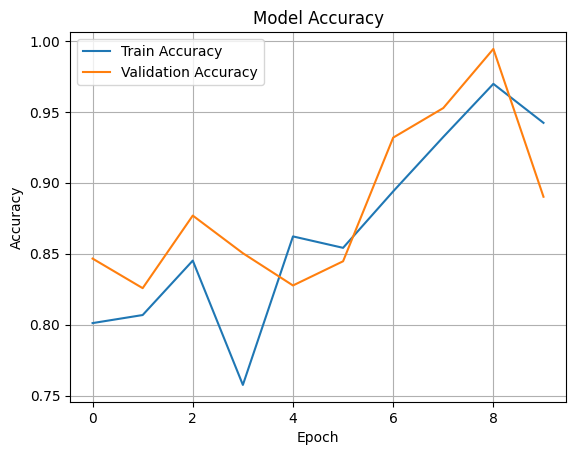

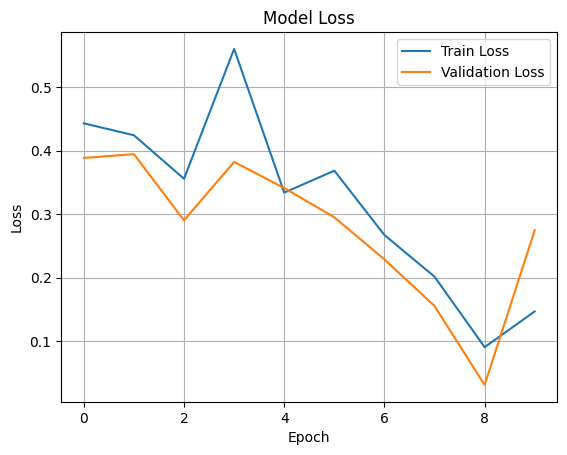

In [45]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
